## Notebook B — Live Data Visualization

Welcome to Notebook B! Here, you will capture the data streamed through OCS and explore it through real-time visualizations.

---
## 6. Receiving OSC in Your App

Below are drop-in snippets for the most common creative coding environments.

### Python

In [3]:
from pythonosc import dispatcher, osc_server
import threading
import time

# =============================================================================
# CLEANUP -- share names with the visualizer cell
# =============================================================================
_prev_srv = globals().get("osc_srv")
_prev_thread = globals().get("srv_thread")

if _prev_srv is not None:
    try:
        _prev_srv.shutdown()
        _prev_srv.server_close()
        print("Closed previous OSC server.")
    except: pass

if _prev_thread is not None:
    _prev_thread.join(timeout=2)

class ReusableOSCUDPServer(osc_server.ThreadingOSCUDPServer):
    allow_reuse_address = True

# =============================================================================
# HANDLERS
# =============================================================================
def on_armband(address, *args):
    channel = int(address.split("/")[-1])
    rms = (sum(v**2 for v in args) / len(args)) ** 0.5
    print(f"Ch{channel}  {len(args):4d} samples  RMS={(1e6*rms):.4f} mV")

def on_imu_accel(address, *args):
    print(f"Accel   ax={args[0]:+.3f}  ay={args[1]:+.3f}  az={args[2]:+.3f} g")

disp = dispatcher.Dispatcher()
for i in range(8):
    disp.map(f"/sifi/emg/{i}", on_armband)
disp.map("/sifi/imu/accel", on_imu_accel)

# =============================================================================
# START SERVER
# =============================================================================
osc_srv = ReusableOSCUDPServer(("0.0.0.0", 9000), disp)
print("Listening on port 9000 — press Stop (Interrupt) to stop")

try:
    # Run in main thread so we can see the print statements easily
    osc_srv.serve_forever()
except KeyboardInterrupt:
    print("\nInterrupted by user.")
finally:
    osc_srv.shutdown()
    osc_srv.server_close()
    print("Server socket released.")

Closed previous OSC server.
Listening on port 9000 — press Stop (Interrupt) to stop
Ch0    14 samples  RMS=6.0785 mV
Ch1    14 samples  RMS=7.4922 mV
Ch2    14 samples  RMS=16.0910 mV
Ch3    14 samples  RMS=2.9995 mV
Ch4    14 samples  RMS=5.0197 mV
Ch5    14 samples  RMS=6.3560 mV
Ch6    14 samples  RMS=2.5931 mV
Ch7    14 samples  RMS=1.8614 mV
Ch0    14 samples  RMS=7.4067 mV
Ch1    14 samples  RMS=6.1468 mV
Ch2    14 samples  RMS=6.0389 mV
Ch3    14 samples  RMS=2.8280 mV
Ch4    14 samples  RMS=5.1874 mV
Ch5    14 samples  RMS=7.7589 mV
Ch6    14 samples  RMS=2.9092 mV
Ch7    14 samples  RMS=3.7811 mV
Ch0    14 samples  RMS=5.3537 mV
Ch1    14 samples  RMS=6.8095 mV
Ch2    14 samples  RMS=13.5878 mV
Ch3    14 samples  RMS=3.2515 mV
Ch4    14 samples  RMS=4.6354 mV
Ch5    14 samples  RMS=5.4072 mV
Ch6    14 samples  RMS=1.9371 mV
Ch7    14 samples  RMS=5.7389 mV
Ch0    14 samples  RMS=2.3081 mV
Ch1    14 samples  RMS=3.6390 mV
Ch2    14 samples  RMS=19.8743 mV
Ch3    14 samples  RMS

### Max/MSP

```
[udpreceive 9000]
        |
   [oscroute /sifi/emg/0 /sifi/emg/1 /sifi/imu/accel /sifi/imu/quat]
     |              |              |              |
  [unpack]      [unpack]       [unpack]       [unpack]
```
*(Repeat `/sifi/emg/0` through `/sifi/emg/7` for all 8 channels)*

### TouchDesigner

1. Add an **OSC In CHOP** node
2. Set **Network Port** to `9000`
3. Channels `/sifi/emg/0` through `/sifi/emg/7`, `/sifi/imu/accel`, etc. appear automatically as CHOP channels

### Pure Data

```pd
[netreceive -u -b 9000]
         |
    [oscparse]
         |
    [route /sifi/emg/0 /sifi/emg/1 /sifi/imu/accel]
```

### SuperCollider

```supercollider
// Register a handler for each of the 8 armband channels
8.do { |i|
    OSCdef((\armband_ ++ i).asSymbol, { |msg|
        var samples = msg[1..];
        var rms = (samples.squared.mean).sqrt;
        ("Ch" ++ i ++ " RMS: " ++ rms).postln;
    }, ("/sifi/emg/" ++ i).asString);
};

OSCdef(\accel, { |msg|
    var ax = msg[1], ay = msg[2], az = msg[3];
    [ax, ay, az].postln;
}, '/sifi/imu/accel');
```

### Sending to a different machine

If your creative software runs on a different computer on the same WiFi network, replace `127.0.0.1` in the streamer with that machine's **local IP address** (e.g. `192.168.1.42`). The OSC port must match on both ends.

---
## 7. Verify OSC: Live Plot from OSC Stream

This cell opens an **OSC receiver** on port 9000 and plots what it receives in real time — directly from the OSC messages, not from the device. Use this to confirm that your streamer is working end-to-end before connecting your creative software.

**Run the OSC streamer from section 5 first** (in a separate terminal or a second Jupyter kernel), then run this cell.

Successfully shut down previous server.


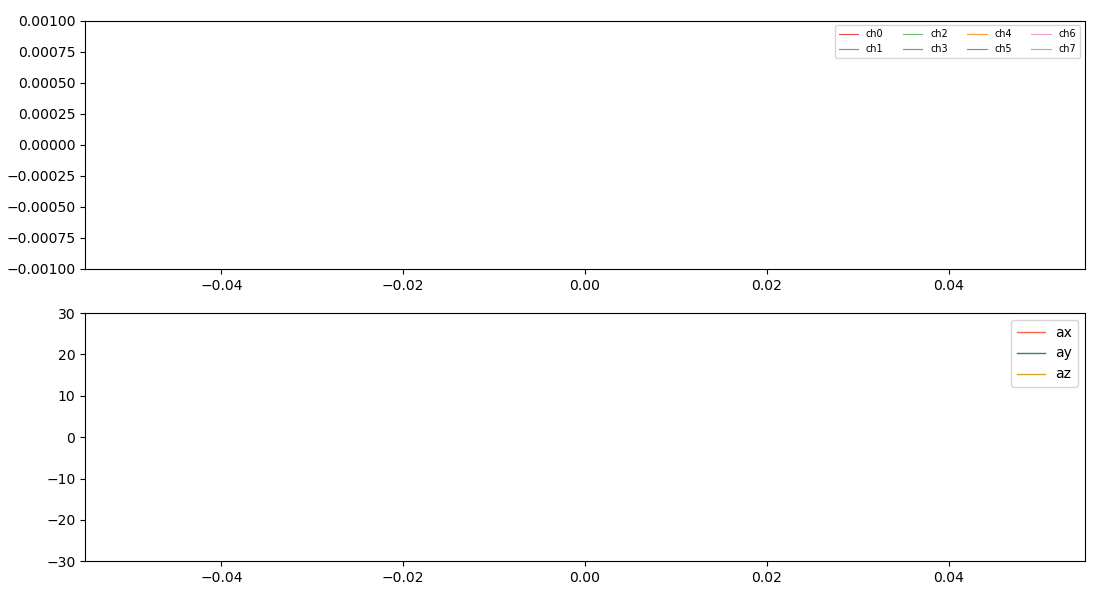

In [6]:
%matplotlib widget

import collections
import threading
import time
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pythonosc import dispatcher, osc_server

# =============================================================================
# CONFIGURATION
# =============================================================================
LISTEN_PORT = 9000   
ARMBAND_WINDOW = 8000 # at 1600 Hz, this is 5 seconds of history
IMU_WINDOW     = 250 # at 50 Hz, this is 5 seconds of history
N_ARMBAND = 8

# =============================================================================
# CLEANUP -- Improved to find server from the simple cell too
# =============================================================================
_prev_srv    = globals().get("osc_srv")
_prev_thread = globals().get("srv_thread")

if _prev_srv is not None:
    try:
        _prev_srv.shutdown()      
        _prev_srv.server_close()  
        print("Successfully shut down previous server.")
    except Exception as e:
        print(f"Cleanup notice: {e}")

if _prev_thread is not None:
    if _prev_thread.is_alive():
        _prev_thread.join(timeout=2)

# =============================================================================
# CLASSES & HELPERS
# =============================================================================
class RateTracker:
    def __init__(self, window=2.0):
        self.window  = window
        self._events = collections.deque()
    def add(self, n=1):
        now = time.time()
        self._events.append((now, n))
        cutoff = now - self.window
        while self._events and self._events[0][0] < cutoff:
            self._events.popleft()
    def rate(self):
        if len(self._events) < 2: return 0.0
        now = time.time()
        total = sum(n for t, n in self._events if t >= now - self.window)
        elapsed = now - self._events[0][0]
        return total / elapsed if elapsed > 0 else 0.0

class ReusableOSCUDPServer(osc_server.ThreadingOSCUDPServer):
    allow_reuse_address = True

# =============================================================================
# DATA STRUCTURES
# =============================================================================
armband_buf = [collections.deque(maxlen=ARMBAND_WINDOW) for _ in range(N_ARMBAND)]
accel_buf   = {axis: collections.deque(maxlen=IMU_WINDOW) for axis in ("ax", "ay", "az")}
rt_armband = RateTracker()   
rt_imu     = RateTracker()

def make_armband_handler(channel_index):
    def handler(address, *args):
        armband_buf[channel_index].extend(args)
        if channel_index == 0: rt_armband.add(len(args))
    return handler

def handle_accel(address, *args):
    if len(args) >= 3:
        accel_buf["ax"].append(args[0]); accel_buf["ay"].append(args[1]); accel_buf["az"].append(args[2])
        rt_imu.add(1)

# =============================================================================
# START OSC RECEIVER
# =============================================================================
disp = dispatcher.Dispatcher()
for _i in range(N_ARMBAND):
    disp.map(f"/sifi/emg/{_i}", make_armband_handler(_i))
disp.map("/sifi/imu/accel", handle_accel)

try:
    osc_srv = ReusableOSCUDPServer(("0.0.0.0", LISTEN_PORT), disp)
except OSError as e:
    raise RuntimeError(f"Port {LISTEN_PORT} is locked. Restart Kernel if cleanup failed.") from e

srv_thread = threading.Thread(target=osc_srv.serve_forever, daemon=True)
srv_thread.start()

# =============================================================================
# PLOTTING
# =============================================================================
fig, (ax_emg, ax_acc) = plt.subplots(2, 1, figsize=(11, 6))

ax_emg.set_ylabel("")
ax_emg.set_ylim(-.001, 0.001)
ARMBAND_COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628", "#f781bf", "#999999"]
lines_armband = [ax_emg.plot([], [], lw=0.8, color=ARMBAND_COLORS[i], label=f"ch{i}", alpha=0.8)[0] for i in range(N_ARMBAND)]
ax_emg.legend(loc="upper right", fontsize=7, ncol=4)

ax_acc.set_ylabel("")
ax_acc.set_ylim(-30, 30)
line_ax, = ax_acc.plot([], [], lw=1.0, color="tomato",    label="ax")
line_ay, = ax_acc.plot([], [], lw=1.0, color="seagreen",  label="ay")
line_az, = ax_acc.plot([], [], lw=1.0, color="goldenrod", label="az")
ax_acc.legend(loc="upper right")

def animate(_):
    n_arm = len(armband_buf[0])
    for i, line in enumerate(lines_armband):
        vals = list(armband_buf[i])
        line.set_data(range(len(vals)), vals) if vals else line.set_data([], [])
    if n_arm: ax_emg.set_xlim(0, n_arm)

    n_acc = len(accel_buf["ax"])
    for line, key in zip([line_ax, line_ay, line_az], ["ax", "ay", "az"]):
        vals = list(accel_buf[key])
        line.set_data(range(len(vals)), vals) if vals else line.set_data([], [])
    if n_acc: ax_acc.set_xlim(0, n_acc)

    arm_rate, imu_rate = rt_armband.rate(), rt_imu.rate()
    fig.suptitle(f"SiFi Band Live  |  EMG: {arm_rate:.0f} Hz  |  IMU: {imu_rate:.0f} Hz", fontsize=10)
    return lines_armband + [line_ax, line_ay, line_az]

ani = animation.FuncAnimation(fig, animate, interval=50, blit=False, cache_frame_data=False)
plt.tight_layout()
plt.show()

In [7]:
# Run this cell to stop the OSC receiver cleanly.
osc_srv.shutdown()     # waits for serve_forever() to exit
osc_srv.server_close() # releases the UDP socket
srv_thread.join(timeout=2)
print("OSC receiver stopped.")

OSC receiver stopped.


---
## 8. OSC Address Reference

| OSC Address | Value types | Signal | Nominal rate |
|---|---|---|---|
| `/sifi/emg/sample_rate` | `float` | — | sent once at start |
| `/sifi/imu/sample_rate` | `float` | — | sent once at start |
| `/sifi/emg/0` | `float, float, …` | EMG ch 0 burst (mV) | 1600 Hz |
| `/sifi/emg/1` | `float, float, …` | EMG ch 1 burst (mV) | 1600 Hz |
| `/sifi/emg/2` | `float, float, …` | EMG ch 2 burst (mV) | 1600 Hz |
| `/sifi/emg/3` | `float, float, …` | EMG ch 3 burst (mV) | 1600 Hz |
| `/sifi/emg/4` | `float, float, …` | EMG ch 4 burst (mV) | 1600 Hz |
| `/sifi/emg/5` | `float, float, …` | EMG ch 5 burst (mV) | 1600 Hz |
| `/sifi/emg/6` | `float, float, …` | EMG ch 6 burst (mV) | 1600 Hz |
| `/sifi/emg/7` | `float, float, …` | EMG ch 7 burst (mV) | 1600 Hz |
| `/sifi/imu/accel` | `ax, ay, az` | Acceleration (g) | 100 Hz |
| `/sifi/imu/quat` | `qw, qx, qy, qz` | Orientation quaternion | 100 Hz |
| `/sifi/temperature` | `float` | Temperature (°C) | 1 Hz |

---

## Tips & Troubleshooting

**Device not found during scan?**
- Make sure it is charged and switched on — look for a LED blinking
- On Windows, you may need to pair the device in Bluetooth Settings first
- Keep the device within 2 m of your laptop during the initial scan

**OSC messages not arriving in my app?**
- Check that the port numbers match on both the sender and receiver
- For cross-machine streaming, replace `127.0.0.1` with the receiver's LAN IP address
- Firewalls can block UDP — temporarily disable or add an inbound exception for the port

**Signal looks very noisy?**
- For EMG: ensure good skin contact — moisten the electrode pads slightly
- Verify `set_filters(enable=True)` was called before `start()`
```

---

Have fun building at MishMash 2026!  
Questions? Find the SiFi Labs team at the hardware table. More documentation can be found here: [docs.sifilabs.com/](https://docs.sifilabs.com/).